<img src="./logoutn.jpg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo Pŕactico de laboratorio 1

Grupo: 1

Alumno: Farcy Facundo

# CONSIGNA
Diseñar, simular y medir un filtro que responda a la siguiente plantilla:
<img src="plantilla.png" display="block" margin=auto width=900>


# DISEÑO

In [2]:
from IPython.display import IFrame
IFrame("TPL1.pdf", width=1000, height=1000)


Finalmente, los valores normalizados quedan:
\begin{equation}
R1 = R3 = R4 = 10k\ohm | R2 = R5 = 18k\ohm
\end{equation}

# SIMULACION
## SIMULACION EN PYTHON
### Transferencia normalizada
Según los cálculos, la trasnferencia de cheby normalizada nos quedó:
\begin{equation}
T(s) = \frac{0,71569}{(s')^3+(s')^2 * 1,252913 +s'*1,5349+0,71569} 
\end{equation}
O, en forma de S.O.S.
\begin{equation}
T(s) = \frac{0,6264565}{(s')+0,6264565}\frac{1,14245}{(s')^2 + s'*0,6264565 +1,14245} 
\end{equation}


Corroboramos si es correcto utilizando la función cheby1

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed May 28 11:18:52 2025

@author: facu
"""

#-------------------------
# IMPORTACIÓN DE MÓDULOS Y CONFIGURACIONES PREVIAS
#------------------------
# Módulos externos

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq, pretty_print_SOS, plot_plantilla
from pytc2.general import print_latex, a_equal_b_latex_s

import matplotlib.patches as patches
from matplotlib.path import Path

def addCuadrado (axe_hdl,att_max=1, att_min=10, wc=1, ws=3,t_min_bottom=-100, t_max_top=100,wi=0,wf=0,i=0,color='red',trama='/',fill=False):
    #wi=winicio
    #wf=wfin
    if wi==0:
        wi=wc/2
    if wf==0:
        wf=ws*2
    #Tmin es determinada por att_max y viceversa
    t_min=1-att_max
    t_max=1-att_min
    
    vert_t_min =[
        (wi, t_min_bottom),  # left, bottom
        (wi, t_min),  # left, top
        (wc, t_min),  # right, top
        (wc, t_min_bottom),  # right, bottom
        (0., 0.),  # ignored
    ]
    vert_t_max =[
        (ws, t_max),  # left, bottom
        (ws, t_max_top),  # left, top
        (wf, t_max_top),  # right, top
        (wf, t_max),  # right, bottom
        (0., 0.),  # ignored
    ]
 
    codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
    
    path_t_min = Path(vert_t_min, codes)
    path_t_max = Path(vert_t_max, codes)
    patch_t_min = patches.PathPatch(path_t_min, color='red', hatch = '/', lw=1, fill=False)
    patch_t_max = patches.PathPatch(path_t_max, color='red', hatch = '/', lw=1, fill=False)
    
    axe_hdl.add_patch(patch_t_min)
    axe_hdl.add_patch(patch_t_max)
    

In [4]:
#----------------------
# INICIO DEL CÓDIGO
#--------------------
n=3
att_min=16
att_max=0.5
wc=1
ws=3
H_C=sig.cheby1(3, att_max, wc, btype='lowpass', analog=True, output='sos', fs=None)
H_C_ba=sig.cheby1(n, att_max, wc, btype='lowpass', analog=True, output='ba', fs=None)
pretty_print_SOS(H_C)

<IPython.core.display.Math object>

Efectivamente, si operamos matemáticamente la expresión de los numeradores, llegamos al mismo resultado obtenido manualmente.
Por último, verificamos si efectivamente este filtro cumple con la plantilla:

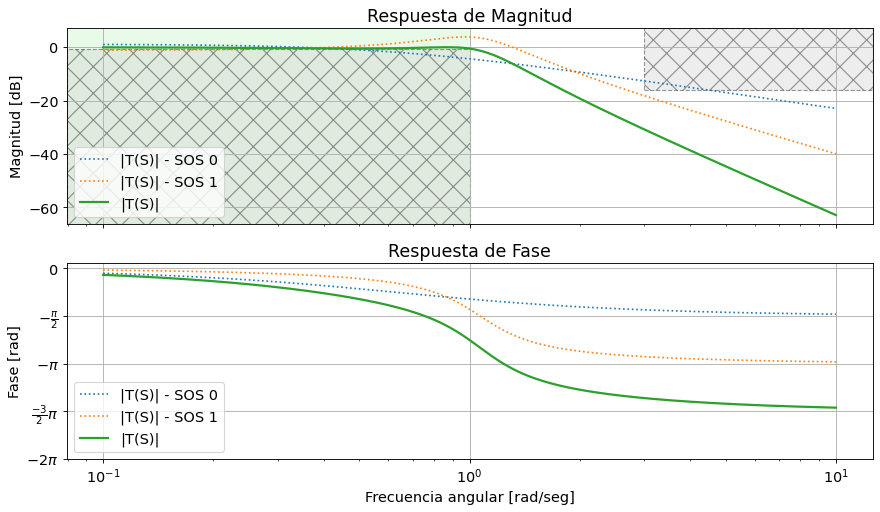

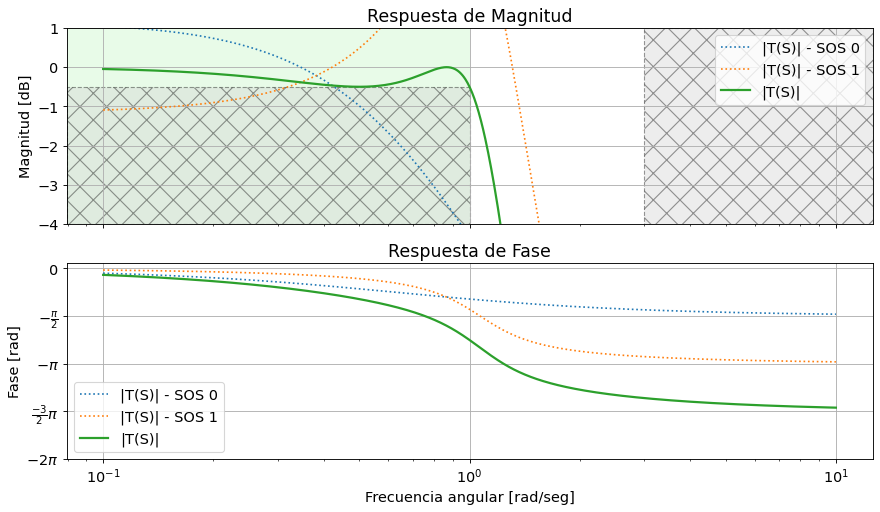

In [5]:

_,axes_hdl_1=bodePlot(H_C, fig_id="1", filter_description="|T(S)|")
_, axes_hdl_2=bodePlot(H_C, fig_id="2", filter_description="|T(S)|")
#axes_hdl_2[0].set_xlim(left=5e3, right=2e4)
axes_hdl_2[0].set_ylim(top=1, bottom=-4);
plt.sca(axes_hdl_1[0])
plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)
plt.sca(axes_hdl_2[0])
plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)


Se puede observar que se cumple con los requerimientos perfectamente.


### TRANSFERENCIA DESNORMALIZADA
Según los cálculos, desnormalizando con:
\begin{equation}
\ohm\omega=3000\pi
\end{equation}
Y tomando como referencia C1 y C2 como:
\begin{equation}
C1=C2=10nF
\end{equation}
Se llega a la siguiente transferencia desnormalizada:
\begin{equation}
T(s) = \frac{5,904e3}{(s')+5,904e3}\frac{101,48e6}{(s')^2 + s'*5,904e3+101,48e6} 
\end{equation}

Comparamos con python, utilizando la misma norma de frecuencia:

In [6]:
wn=3000*np.pi
wn_pot = [0,1,2,0,1,2]

for i in range(0,6):
    wn_pot[i]=np.power(wn,wn_pot[i])
wn_pot = np.array(wn_pot)

i = int(len(H_C)/2 + 1)
for n in range(0,i):
    for m in range (0,6):
        #print("%d , %d" % (n, m))
        #print("%f \n %f" % (H_C[n][m],wn_pot[m])) 
        #print("--------------")
        H_C[n][m]=H_C[n][m] * wn_pot[m]
        #print(H_C[n][m])
        #print("...........................")
pretty_print_SOS(H_C)  


<IPython.core.display.Math object>

Nuevamente, si se opera con los numeradores y se redondean los valores, llegamos al mismo resultado que teóricamente.
Por último, chequeamos cumplimiento de la plantilla

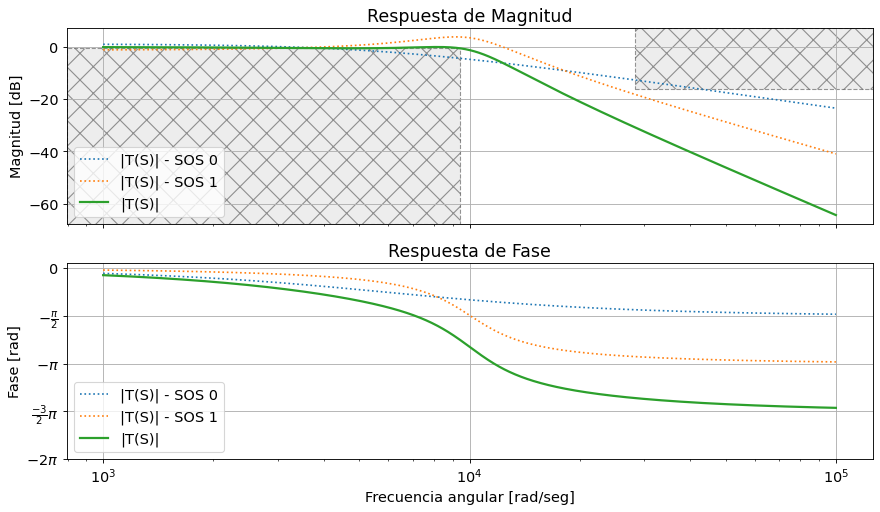

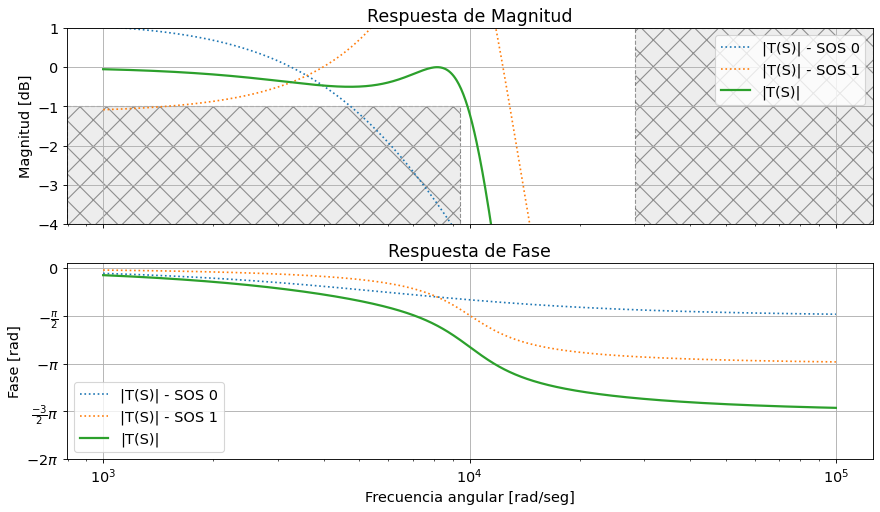

In [7]:

_,axes_hdl_1=bodePlot(H_C, fig_id="1", filter_description="|T(S)|")
_, axes_hdl_2=bodePlot(H_C, fig_id="2", filter_description="|T(S)|")
#axes_hdl_2[0].set_xlim(left=5e3, right=2e4)
axes_hdl_2[0].set_ylim(top=1, bottom=-4);
plt.sca(axes_hdl_1[0])
plot_plantilla(filter_type="lowpass", fpass=1.0*wn, ripple=0.5, fstop=3.0*wn, attenuation=16)
plt.sca(axes_hdl_2[0])
plot_plantilla(filter_type="lowpass", fpass=1.0*wn, ripple=1, fstop=3.0*wn, attenuation=16)

### TRANSFERENCIA CON VALORES DE COMPONENTES
Con los valores de los componentes y las funciones transferencias de los circuitos propuestos, verificamos si se cumple lo deseado

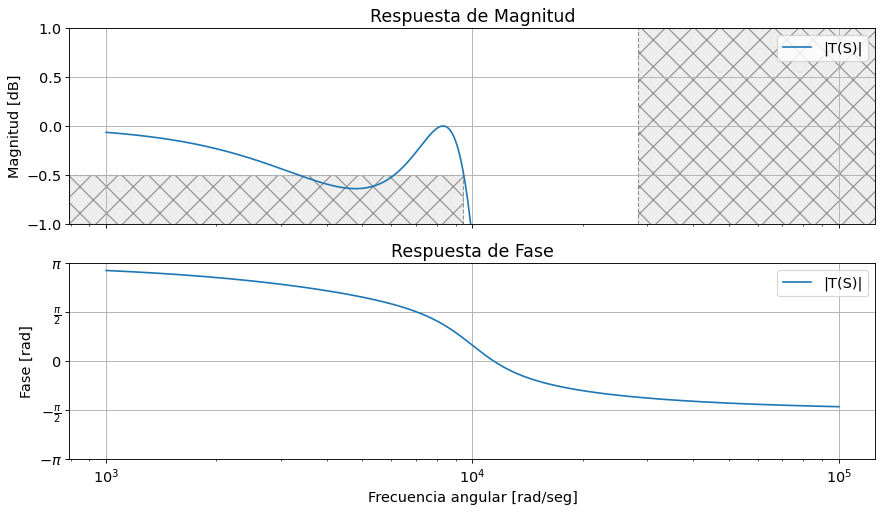

In [20]:
#------ VALORES
R1=R3=R4=10e3
R2=R5=18e3
C1=C2=10e-9

G1=1/R1
G2=1/R2
G3=1/R3
G4=1/R4
G5=1/R5


num_H1= -G1/G3*np.array([0., 0., (G3/C1)**2])
den_H1= np.array([1.,G2/C1,(G3/C1)**2])
num_H2= np.array([0., 0., G5/C2])
den_H2= np.array([0., 1., G5/C2])


num_H = np.polymul(num_H1, num_H2)
den_H = np.polymul(den_H1, den_H2)

#H1 = sig.TransferFunction(num_H1, den_H1)
#H2 = sig.TransferFunction(num_H2, den_H2)
H = sig.TransferFunction(num_H, den_H)

#_, axes_hdl_4=bodePlot(H1, fig_id="4", filter_description="|T1(S)|")
#_,_,=bodePlot(H2, fig_id="4", filter_description="|T2(S)|")
_, axes_hdl_=bodePlot(H, fig_id="4", filter_description="|T(S)|")
axes_hdl_[0].set_ylim(top=1, bottom=-1);
plt.sca(axes_hdl_[0])
plot_plantilla(filter_type="lowpass", fpass=1.0*wn, ripple=0.5, fstop=3.0*wn, attenuation=16)



Como se puede observar, con los valores normalizados parece no cumplir con los requisitos el filtro. Sin embargo, respetando el valor de R2 y R5 originales...

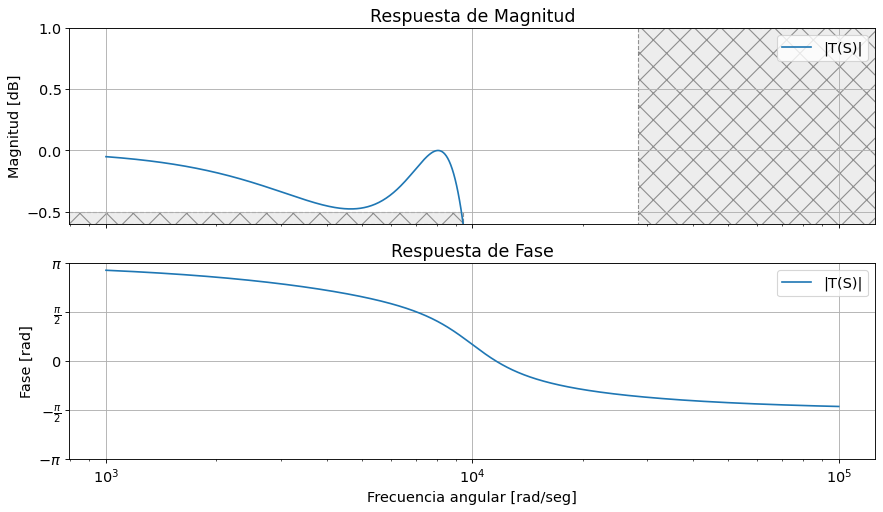

In [21]:
R2=R5=16.9e3
G2=1/R2
G5=1/R5

num_H1= -G1/G3*np.array([0., 0., (G3/C1)**2])
den_H1= np.array([1.,G2/C1,(G3/C1)**2])
num_H2= np.array([0., 0., G5/C2])
den_H2= np.array([0., 1., G5/C2])


num_H = np.polymul(num_H1, num_H2)
den_H = np.polymul(den_H1, den_H2)

#H1 = sig.TransferFunction(num_H1, den_H1)
#H2 = sig.TransferFunction(num_H2, den_H2)
H = sig.TransferFunction(num_H, den_H)

#_, axes_hdl_4=bodePlot(H1, fig_id="4", filter_description="|T1(S)|")
#_,_,=bodePlot(H2, fig_id="4", filter_description="|T2(S)|")
_, axes_hdl_=bodePlot(H, fig_id="4", filter_description="|T(S)|")
axes_hdl_[0].set_ylim(top=1, bottom=-0.6);
plt.sca(axes_hdl_[0])
plot_plantilla(filter_type="lowpass", fpass=1.0*wn, ripple=0.5, fstop=3.0*wn, attenuation=16)

Se puede ver que si se respetara el valor de R2 y R5, se cumplirían los requerimientos de la plantilla. Teniendo esto en cuenta, para el desarrollo de la práctica se hará uso de una resistencia multivuelta para reemplazar a R2 y R5, para llegar a un valor que nos sirva para cumplir con la plantilla.

## SIMULACION LT SPICE

En SPICE obtuvimos lo siguiente

<img src="spice1.png" display="block" margin=auto width=900>
<img src="spice2.png" display="block" margin=auto width=900>
<img src="spice3.png" display="block" margin=auto width=900>


En concordancia con la simulación en python, vemos que para los valores normalizados hay una atenuación superior a 0.5dB en la banda de paso. Sin embargo, fijando los valroes de R2 y R5 a los originales, se vuelve a solucionar el problema:
<img src="spice4.png" display="block" margin=auto width=900>

# PRACTICA

## MEDICIÓN CON OSCILOSCOPIO
En el laboratorio primeramente buscamos obtener la respuesta de amplitud y frecuencia del filtro, utilizando el osciloscopio.Para ello colocamos un canal en paralelo la entrada del filtro, a su vez conectada a un generador de señales con una senoidal de 10Vpp, y con otro canal medimos la tensión sobre la salida. Procedimos a variar la frecuencia en un rango de 100Hz hasta 9,5kHz y tomar nota de aproximadamente 35 puntos diferentes, anotando valores de amplitud de ambos canales y la diferencia temporal de los máximos para calcular indirectamente el desfasaje. 
<br>
<img src="foto2.png"></img>



In [38]:
from IPython.display import Video
Video("barrido.mp4", width=640, height=400)

Con dichos puntos, llegamos al siguiente gráfico:

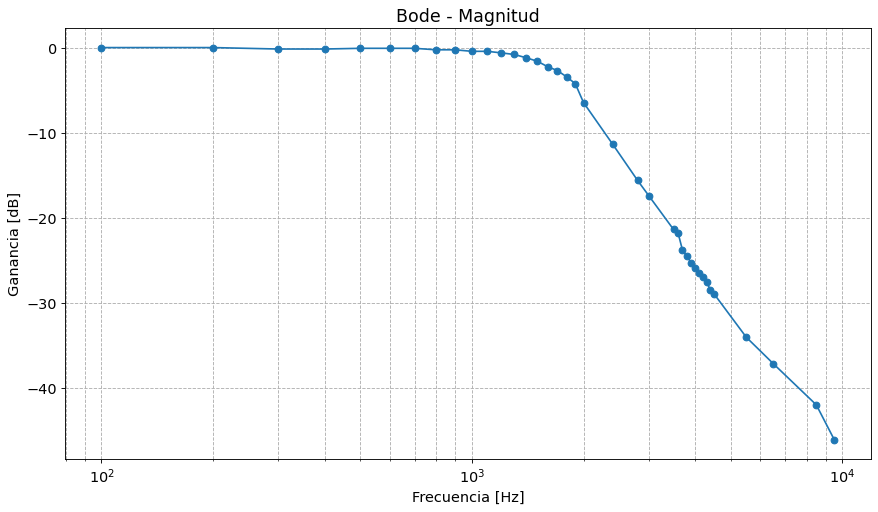

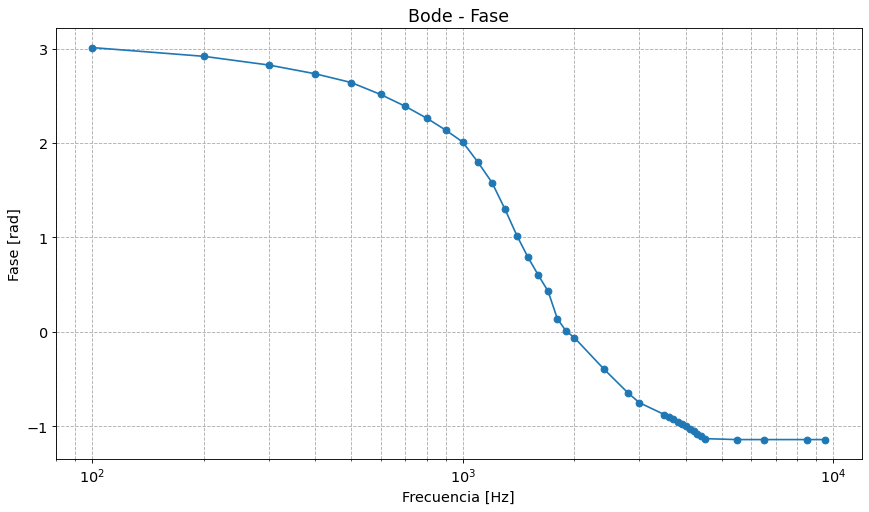

In [39]:
data = np.genfromtxt("mediciones.csv", delimiter=",", skip_header=1, dtype=float)

Vin  = data[:,0]
Vout = data[:,1]
Frec = 1e3*data[:,2]
Phas = data[:,3]

ganancia_db = 20 * np.log10(Vout / Vin)

plt.semilogx(Frec, ganancia_db, marker="o")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Bode - Magnitud")
plt.grid(True, which="both", ls="--")
plt.show()

#Interpolación para la fase
mask = np.isfinite(Phas)
F_valid   = Frec[mask]
Ph_valid  = np.unwrap(Phas[mask])
Ph_interp_unwrapped = np.interp(Frec, F_valid, Ph_valid)

plt.figure()
plt.semilogx(Frec, Ph_interp_unwrapped, marker="o", linestyle="-")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")  # eje en radianes
plt.title("Bode - Fase")
plt.grid(True, which="both", ls="--")
plt.show()


Respecto a la fase, nos dió según lo esperado, presentando la mitad del desenvolvimiento (3/4 de pi, aproximadamente 2,35rad) en la frecuencia de corte 1,5kHz. 
Respecto a la amplitud, dio según lo esperado, pero la oscilación sobre la banda de paso fue apenas perceptible. A pesar de que en el gráfico a primera vista no se perciba, si hacemos zoom sobre la banda de paso se puede apreciar levemente:

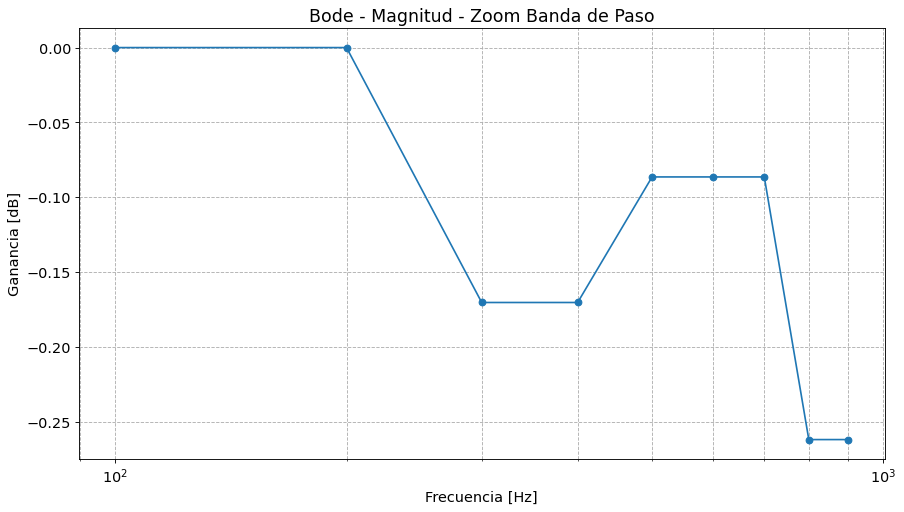

In [40]:

plt.semilogx(Frec[:9], ganancia_db[:9], marker="o")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Bode - Magnitud - Zoom Banda de Paso")
plt.grid(True, which="both", ls="--")
plt.show()

## MEDICIÓN CON ANALIZADOR DE AUDIO
Además de la medición con osciloscopio, realizamos una caracterización del filtro con un analizador de audio
<br>
<div style="display:flex;">
  <img src="foto1.png">

  <img src="foto2.png">
</div>

Obteniendo los siguientes resultados
<br>
    <img src="LPF_Modulo.jpeg" style="height:400px;">
    <img src="LPF_Fase.jpeg" style="height:400px;">

# COCLUSION
Luego de haber contrastado los resultados experimentales con los esperados teóricos, concluimos que es posible obtener respuestas más que aceptables al llevar los filtros a la realidad. Sin embargo, es necesario contar con mecanismos de ajuste fino de componentes, como los potenciometros multivuelta que se utilizaron para R2 y R5.
A su vez, pudimos comprobar que en la frecuencia de corte el desenvolvimiento de fase es la mitad del total, y que la atenuación fuera de la banda de paso es de aproximadamente 20dB/dec por cada polo.